# Zomato Bangalore Restaurant Analysis

**Business question:** What drives restaurant ratings in Bangalore, and which areas offer room for a better restaurant?

**Dataset:** Zomato Bangalore Restaurants (Kaggle), about 51K raw records.

**Tools:** Python, Pandas, Seaborn, Scikit-learn


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 1. Data Loading and Inspection
Loaded the dataset and checked its shape, column types, nulls and duplicates.

In [5]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/datasets/zomato.csv")
print(df.shape)


(51717, 17)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [7]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [8]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


The raw data has 17 columns with missing values in rating, cost and dish_liked. No exact duplicates were found at this stage.

In [9]:
df.duplicated().sum()

np.int64(0)

## 2. Data Cleaning
Steps taken:
- Dropped unneeded columns (url, phone, menu_item)
- Renamed long column names
- Converted rating from text ("4.1/5") to numeric; "NEW" and "-" became null
- Converted cost-for-two to numeric (removed commas)
- Dropped rows missing rating or cost, because they are core to the analysis
- Filled missing dish_liked with "Not available" to avoid losing about half the data
- Standardized text casing and removed duplicates

In [10]:
df=df.drop(columns=["url","phone","menu_items"],errors="ignore")
df=df.rename(columns={"approx_cost(for two people)":"cost_for_two","listed_in(type)":"service_type","listed_in(city)":"city_area"})

In [11]:
df["rate"]=df["rate"].astype(str).str.replace("/5","",regex=False).str.strip()
df["rate"]=pd.to_numeric(df["rate"],errors="coerce")


In [12]:
df["cost_for_two"]=pd.to_numeric(
    df["cost_for_two"].astype(str).str.replace(",",""),errors='coerce')

In [13]:

df=df.dropna(subset=["rate","cost_for_two"])
df["cuisines"]=df["cuisines"].fillna("Unknown")
df["rest_type"]=df["rest_type"].fillna("Unknown")

In [14]:
print(df.shape)
df.info()
df.isnull().sum()

(41418, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 41418 entries, 0 to 51716
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   address       41418 non-null  object 
 1   name          41418 non-null  object 
 2   online_order  41418 non-null  object 
 3   book_table    41418 non-null  object 
 4   rate          41418 non-null  float64
 5   votes         41418 non-null  int64  
 6   location      41418 non-null  object 
 7   rest_type     41418 non-null  object 
 8   dish_liked    23327 non-null  object 
 9   cuisines      41418 non-null  object 
 10  cost_for_two  41418 non-null  float64
 11  reviews_list  41418 non-null  object 
 12  menu_item     41418 non-null  object 
 13  service_type  41418 non-null  object 
 14  city_area     41418 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 5.1+ MB


,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,18091
cuisines,0


In [15]:
df["dish_liked"]=df["dish_liked"].fillna("Not available")


In [16]:
df.isnull().sum()

,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0


In [17]:
for col in ["online_order","book_table","service_type","city_area"]:
  print(df[col].value_counts(),"/n")

online_order
Yes    27206
No     14212
Name: count, dtype: int64 /n
book_table
No     35114
Yes     6304
Name: count, dtype: int64 /n
service_type
Delivery              20540
Dine-out              14128
Desserts               2714
Cafes                  1511
Drinks & nightlife     1045
Buffet                  848
Pubs and bars           632
Name: count, dtype: int64 /n
city_area
BTM                      2599
Koramangala 7th Block    2371
Koramangala 4th Block    2262
Koramangala 5th Block    2260
Koramangala 6th Block    2128
Jayanagar                1923
JP Nagar                 1645
Indiranagar              1544
Church Street            1518
MG Road                  1515
Brigade Road             1483
Lavelle Road             1451
Residency Road           1345
HSR                      1335
Marathahalli             1305
Bannerghatta Road        1217
Whitefield               1206
Old Airport Road         1178
Brookefield              1150
Basavanagudi             1072
Sarjapur Road     

In [18]:
for col in ["location","rest_type","cuisines","city_area"]:
  df[col]=df[col].astype(str).str.strip().str.title()

In [19]:
df=df.drop_duplicates()

In [20]:
print(df["cost_for_two"].describe())
print(df["rate"].describe())

count    41392.000000
mean       603.265269
std        464.326729
min         40.000000
25%        300.000000
50%        500.000000
75%        700.000000
max       6000.000000
Name: cost_for_two, dtype: float64
count    41392.000000
mean         3.700370
std          0.440687
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64


In [21]:
print(df.shape)

(41392, 15)


Final clean dataset: **41,392 rows and 15 columns**. Ratings range from 1.8 to 4.9. Cost ranges from ₹40 to ₹6,000; extreme values are premium restaurants, so they were kept.

In [22]:
df.to_csv("zomato_clean.csv",index=False)

## 3. Exploratory Data Analysis
### 3.1 Distributions

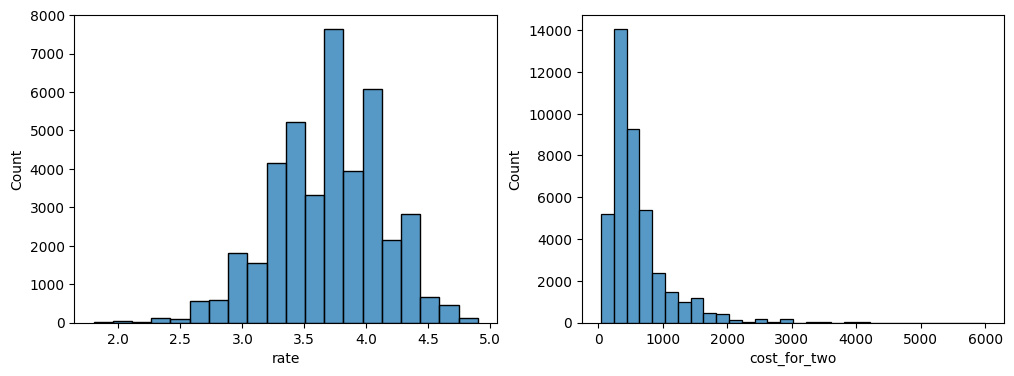

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.histplot(df["rate"],bins=20,ax=ax[0])
sns.histplot(df["cost_for_two"],bins=30,ax=ax[1])
plt.show()

**Insight:** Ratings are bell-shaped, peaking around 3.7 to 3.8. Cost is right-skewed, with most restaurants charging ₹300 to ₹500 for two and a long tail of expensive places.

### 3.2 Relationships
Compared ratings across online ordering, table booking and cost.

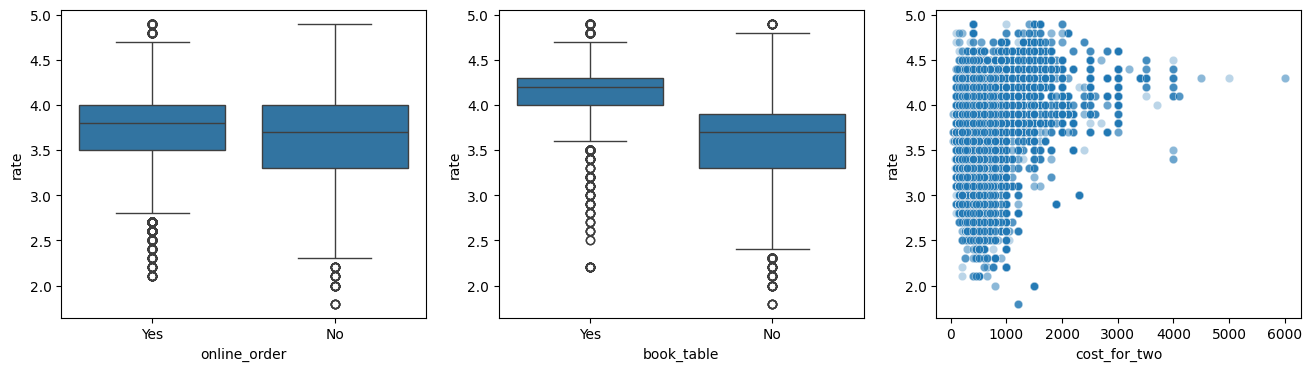

                  rate  cost_for_two     votes
rate          1.000000      0.385060  0.434745
cost_for_two  0.385060      1.000000  0.366689
votes         0.434745      0.366689  1.000000


In [24]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
sns.boxplot(x="online_order",y="rate",data=df,ax=ax[0])
sns.boxplot(x="book_table",y="rate",data=df,ax=ax[1])
sns.scatterplot(x="cost_for_two",y="rate",data=df,alpha=0.3,ax=ax[2])
plt.show()
print(df[["rate","cost_for_two","votes"]].corr())

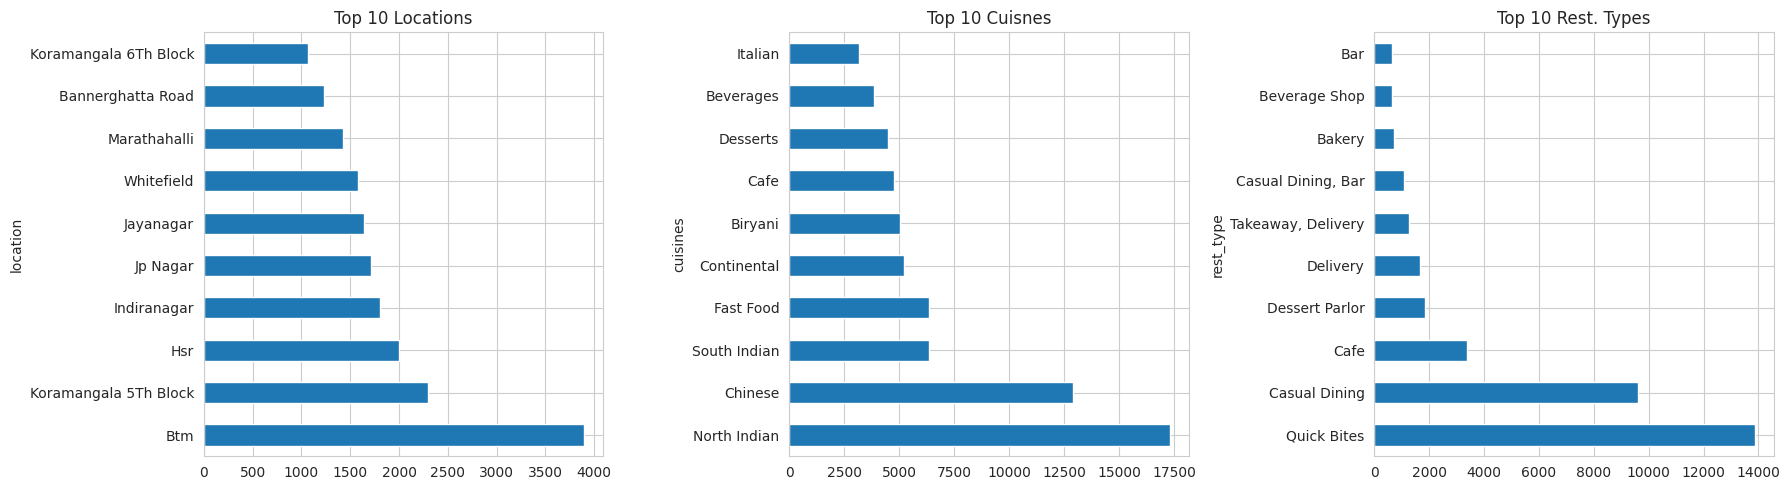

In [32]:
fig, ax=plt.subplots(1,3,figsize=(18,5))
df["location"].value_counts().head(10).plot(kind="barh",ax=ax[0],title="Top 10 Locations")
cuisnes=df["cuisines"].str.split(",").explode().str.strip()
cuisnes.value_counts().head(10).plot(kind="barh",ax=ax[1],title="Top 10 Cuisnes")
df["rest_type"].value_counts().head(10).plot(kind="barh",ax=ax[2],title="Top 10 Rest. Types")
plt.tight_layout()
plt.show()

**Insight:**
- Online ordering has only a small effect on rating (median about 3.8 vs 3.7).
- Table booking has a strong effect (median about 4.2 vs 3.7).
- Higher cost does not guarantee a high rating, but expensive places (₹1,500+) rarely rate below 3.5.

### 3.3 Segments: Locations, Cuisines and Restaurant Types

In [26]:
print(df.groupby("location")["rate"].mean().sort_values(ascending=False).head(10))
df_c=df.assign(cuisine=df["cuisines"].str.split(",")).explode("cuisine")
df_c["cuisine"]=df_c["cuisine"].str.strip()
top=df_c.groupby("cuisine")["rate"].agg(["mean","count"])
print(top[top["count"]>100].sort_values("mean",ascending=False).head(10))

location
Lavelle Road             4.141545
Koramangala 3Rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5Th Block    4.006925
Church Street            3.992125
Sankey Road              3.965385
Koramangala 4Th Block    3.918668
Cunningham Road          3.900633
Residency Road           3.864511
Koramangala 7Th Block    3.852986
Name: rate, dtype: float64
                   mean  count
cuisine                       
Modern Indian  4.308276    145
Malaysian      4.306422    109
Japanese       4.258235    340
Mediterranean  4.213187    546
European       4.166181    686
Korean         4.149645    141
Asian          4.135578   1203
Steak          4.090235    553
American       4.070668   1333
Salad          4.065316   1061


### 3.4 Hidden Gems and Market Gaps
The same restaurant appeared under multiple service types, which inflated counts. I created `df_unique` (one row per restaurant and location) and used it for all further analysis.

In [27]:
# Remove duplicate restaurants (same restaurant listed under multiple service types)
df_unique = df.drop_duplicates(subset=["name", "location"])
print(df_unique.shape)

# 1. Hidden gems
gems = df_unique[(df_unique["rate"] >= 4.2) & (df_unique["votes"] < 100)]
print("Hidden gems:", len(gems))
print(gems[["name", "location", "cuisines", "rate", "votes", "cost_for_two"]].head(10))

# 2. Area analysis
area = df_unique.groupby("location").agg(
    restaurants=("name", "count"),
    avg_rate=("rate", "mean"),
    avg_cost=("cost_for_two", "mean")
)
area = area[area["restaurants"] > 30]

# Crowded but low-rated areas
print(area.sort_values(["restaurants", "avg_rate"], ascending=[False, True]).head(10))

# Fewer restaurants but high rating (underserved)
print(area.sort_values(["restaurants", "avg_rate"], ascending=[True, False]).head(10))

(9220, 15)
Hidden gems: 56
                                      name               location  \
174                           Energy Addaa           Basavanagudi   
297                      Udupi Ruchi Grand           Banashankari   
2546                           Dr. Bubbles              Jayanagar   
2802         Marzipan @ The Bohemian House          Richmond Road   
3970                       The Kebab House              Bellandur   
3986                     Parrattha Ssinghh           Marathahalli   
5053               Japan Travel Cafe Azuki         Residency Road   
5234                       Hotel Ramprasad           Brigade Road   
5268                           Sweet Truth  Koramangala 8Th Block   
5343  Mangalore pearl - Seafood Restaurant                 Ulsoor   

                                               cuisines  rate  votes  \
174   Salad, Healthy Food, Sandwich, Juices, Burger,...   4.2     64   
297    South Indian, North Indian, Chinese, Street Food   4.2     60 

**Insight:**
- **[X] hidden gems** found: rating 4.2 or higher with under 100 votes. They are mostly affordable places (₹200 to ₹700).
- **BTM** is the most crowded area with a below-average rating, which leaves room for a better restaurant.
- **Koramangala 5th Block** is crowded and highly rated, so it is a tough market.

## 4. Predictive Modeling
Goal: predict restaurant rating and identify the strongest drivers.

Features: online ordering, table booking, votes, cost-for-two, location (top 15) and restaurant type (top 15). Data was split 80/20 for training and testing.

R2: 0.3718135278414927
MAE: 0.2502303991788164
votes                       0.571371
cost_for_two                0.138759
online_order                0.030595
location_Other              0.020979
rest_type_Quick Bites       0.017215
rest_type_Casual Dining     0.016665
rest_type_Dessert Parlor    0.015217
location_Marathahalli       0.014261
book_table                  0.012717
location_Whitefield         0.011787
dtype: float64


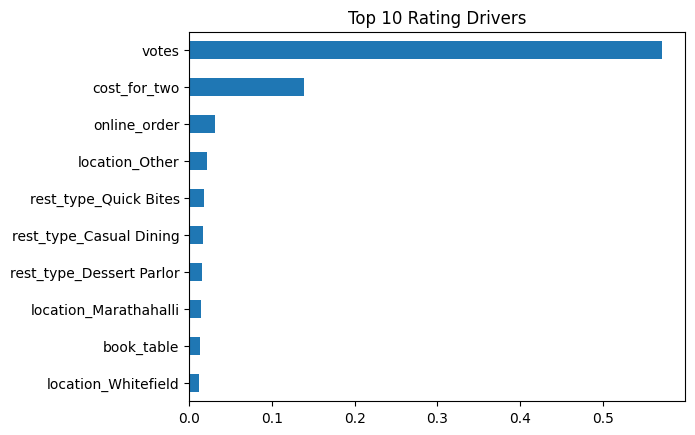

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error

data=df_unique[["online_order","book_table","votes","cost_for_two","location","rest_type","rate"]].copy()

data["online_order"]=(data["online_order"]=="Yes").astype(int)
data["book_table"]=(data["book_table"]=="Yes").astype(int)
for col in ["location","rest_type"]:
  top=data[col].value_counts().head(15).index
  data[col]=data[col].where(data[col].isin(top),"Other")

data=pd.get_dummies(data,columns=["location","rest_type"],drop_first=True)

X=data.drop(columns="rate")
y=data["rate"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
model.fit(X_train,y_train)

pred=model.predict(X_test)
print("R2:",r2_score(y_test,pred))
print("MAE:",mean_absolute_error(y_test,pred))

imp=pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)
print(imp.head(10))
imp.head(10).plot(kind="barh",title="Top 10 Rating Drivers")
plt.gca().invert_yaxis()
plt.show()

**Random Forest:** R2 = 0.37, MAE = 0.25. Votes (57%) and cost-for-two (14%) were the strongest predictors.

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
print("GB R2:", r2_score(y_test, gb.predict(X_test)))

GB R2: 0.43941376145398214


**Gradient Boosting:** R2 = 0.44, MAE = [your MAE]. It outperformed Random Forest and was selected as the final model.

**Caveat:** Votes are partly a result of popularity, so they are a strong predictor, not necessarily a cause of high ratings. Taste and service quality are not in the data, which limits accuracy.

## 5. Final Visualizations
Key charts summarizing the findings.

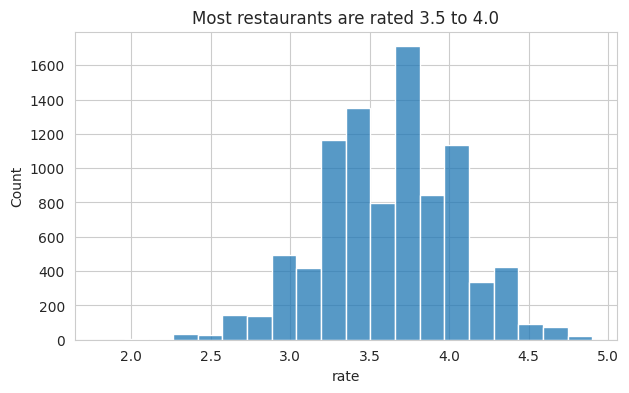

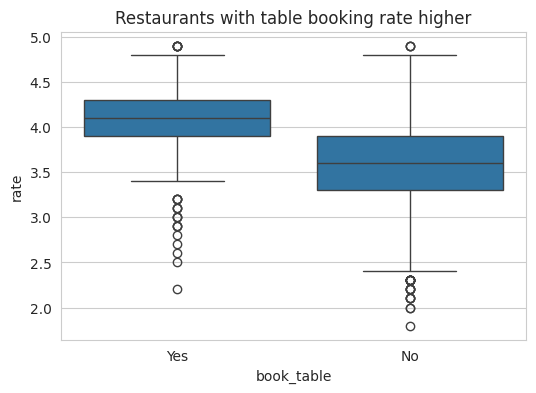

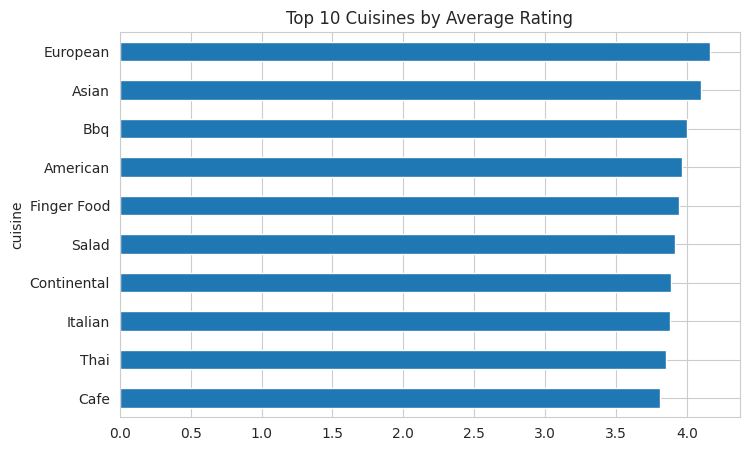

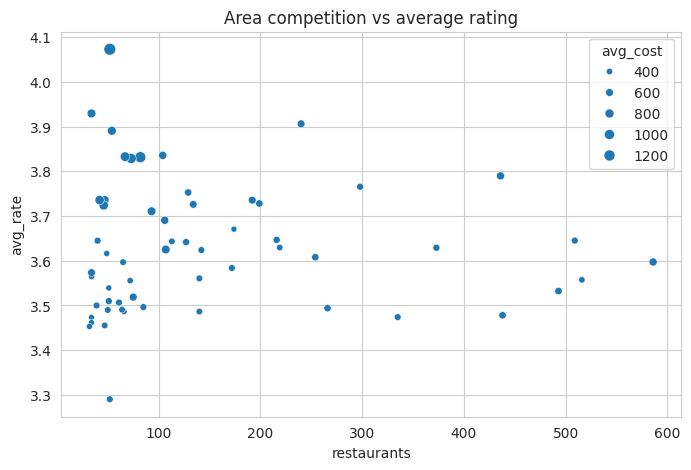

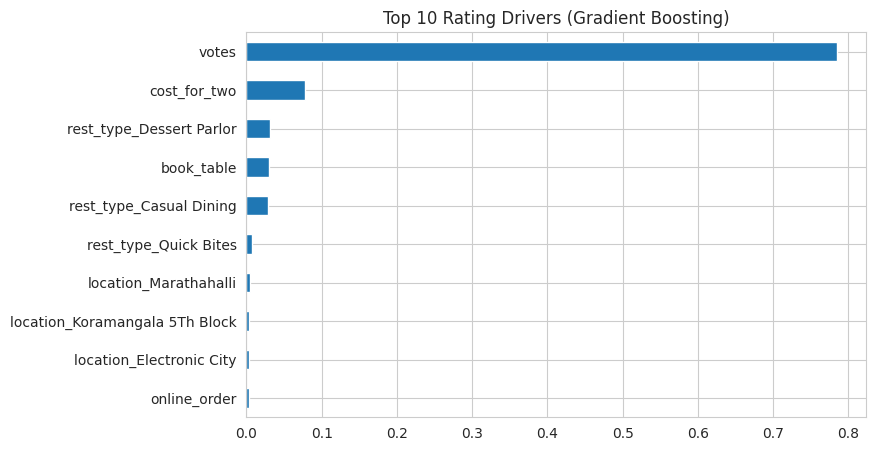

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# 1. Rating distribution
plt.figure(figsize=(7,4))
sns.histplot(df_unique["rate"], bins=20)
plt.title("Most restaurants are rated 3.5 to 4.0")
plt.savefig("1_rating_dist.png", dpi=150, bbox_inches="tight"); plt.show()

# 2. Table booking vs rating
plt.figure(figsize=(6,4))
sns.boxplot(x="book_table", y="rate", data=df_unique)
plt.title("Restaurants with table booking rate higher")
plt.savefig("2_booking.png", dpi=150, bbox_inches="tight"); plt.show()

# 3. Best-rated cuisines (100+ restaurants)
c = df_unique.assign(cuisine=df_unique["cuisines"].str.split(",")).explode("cuisine")
c["cuisine"] = c["cuisine"].str.strip()
top = c.groupby("cuisine")["rate"].agg(["mean","count"])
top = top[top["count"] > 100].sort_values("mean", ascending=False).head(10)
plt.figure(figsize=(8,5))
top["mean"].plot(kind="barh", title="Top 10 Cuisines by Average Rating")
plt.gca().invert_yaxis()
plt.savefig("3_cuisines.png", dpi=150, bbox_inches="tight"); plt.show()

# 4. Crowding vs quality by area
plt.figure(figsize=(8,5))
sns.scatterplot(x="restaurants", y="avg_rate", size="avg_cost", data=area)
plt.title("Area competition vs average rating")
plt.savefig("4_areas.png", dpi=150, bbox_inches="tight"); plt.show()

# 5. Model drivers
imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
imp.head(10).plot(kind="barh", title="Top 10 Rating Drivers (Gradient Boosting)")
plt.gca().invert_yaxis()
plt.savefig("5_drivers.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Conclusion and Recommendations
1. **Target crowded but low-rated areas** like BTM with a higher-quality offering.
2. **Offer table booking**, which is linked to higher ratings.
3. **Promote hidden gems**: high-rated restaurants with low visibility.
4. **Price in the ₹300 to ₹700 range**, where most demand and competition sit.

**Limitations:** No review text or time data; votes reflect popularity; cost outliers were kept.